## **Support Vector Machines com Biblioteca de sua escolha (SVM)**
**Gustavo Pereira Prado | 11241104195**

**Isabelli Reno | 11241100124**

Objetivo: Implementar SVM na biblioteca de sua escolha (kaggle)

## **Sobre o DataSet**

Informações sobre a quantidade de *Bloons* em cada rodada do BTD6.

RBE significa Equivalente de Balão Vermelho (Red Bloon Equivalent). Como um balão vermelho sofre dano para ser destruído, essa unidade essencialmente mede a vida de cada tipo de inimigo. Vermelho, Azul, Verde, Amarelo e Rosa se referem aos tipos de *Bloons* mais básicos. O vermelho é o mais lento e o rosa é o mais rápido. O rosa se transforma em um amarelo, que se transforma em um verde ao sofrer dano. Isso também se aplica de verde para azul e de azul para vermelho. *Bloons* pretos são imunes a dano explosivo. *Bloons* brancos são imunes a congelamento. *Bloons* zebra são imunes a dano explosivo e congelamento. *Bloons* roxos são imunes a dano de fogo e energia. *Bloons* de chumbo são imunes a qualquer dano "afiado", geralmente precisando ser explodidos ou derretidos. *Bloons* arco-íris não têm imunidades, mas se transformam em dois *Bloons* zebra. *Bloons* de cerâmica têm muita vida.

Mais tarde, você encontrará uma classe de *Bloons* completamente diferente. Começando pelos MOABs. Esses inimigos se assemelham a dirigíveis e têm ainda mais vida do que os inimigos anteriores. Em seguida, você encontrará os BFBs, depois os ZOMGs e, por fim, os BADs. Nessa fase, você já estará bem perto do final do jogo.

Além disso, os *Bloons* podem ser modificados de três maneiras: *Bloons* camuflados só podem ser alvejados por torres que conseguem detectar camuflagem; *Bloons* regenerativos (ou de crescimento) recuperam lentamente a saúde perdida se não forem danificados por um determinado período; *Bloons* fortificados têm o dobro da saúde normal.

Meu conjunto de dados lista a quantidade e o tipo de *Bloons* que você encontrará nas primeiras 140 rodadas do jogo.

## **1. Importação de bibliotecas**
Este bloco importa todas as ferramentas essenciais para o projeto. Inclui bibliotecas para manipulação de dados (pandas, numpy), visualização gráfica (matplotlib, seaborn), integração com o Kaggle (kagglehub) e algoritmos de Machine Learning, especificamente as ferramentas de pré-processamento, métricas e o modelo Support Vector Machine (SVM) do scikit-learn

In [72]:
# Import de bibliotecas
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import kagglehub

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_curve, roc_auc_score

sns.set_theme(style = "whitegrid")
plt.rcParams["figure.figsize"] = (5, 4)

## **2. Carregamento de dados**
O código faz o download automático da base de dados dos rounds 1 a 140 do jogo BTD6 diretamente do Kaggle. Em seguida, ele localiza o arquivo CSV baixado, carrega as informações (como quantidade de balões Red, Blue, MOABs, etc.) para uma tabela de dados (DataFrame) e exibe as 5 primeiras linhas.

In [73]:
path = kagglehub.dataset_download("brandonconrady/bloons-tower-defense-6-rounds-1140")
print("Path to dataset files:", path)

csv_file = None
for root, dirs, files in os.walk(path):
  for file in files :
    if file.endswith(".csv"):
      csv_file = os.path.join(root, file)
      break

if csv_file:
  df = pd.read_csv(csv_file)
  print(f"\nArquivo '{os.path.basename(csv_file)}' carregado com sucesso.")
  print(df.head())
else:
  raise FileNotFoundError("Nenhum arquivo CSV foi encontrado.")

Using Colab cache for faster access to the 'bloons-tower-defense-6-rounds-1140' dataset.
Path to dataset files: /kaggle/input/bloons-tower-defense-6-rounds-1140

Arquivo 'BTD6_Rounds.csv' carregado com sucesso.
   Round  RBE  Red  Blue  Green  Camo_Green  Camo_Regen_Green  Yellow  \
0      1   20   20     0      0           0                 0       0   
1      2   35   35     0      0           0                 0       0   
2      3   35   25     5      0           0                 0       0   
3      4   71   35    18      0           0                 0       0   
4      5   59    5    27      0           0                 0       0   

   Regen_Yellow  Camo_Yellow  ...  MOAB  Fortified_MOAB  BFB  Fortified_BFB  \
0             0            0  ...     0               0    0              0   
1             0            0  ...     0               0    0              0   
2             0            0  ...     0               0    0              0   
3             0            0  ... 

## **3. Análise Exploratoria de Dados (EDA)**
Aqui, o código examina a estrutura da tabela (linhas, colunas e contagem de valores) e remove colunas vazias ou identificadores desnecessários. O passo crucial é a criação da variável alvo Target_Dificuldade. O código calcula a mediana da coluna RBE (Red Bloon Equivalent, que mede a força total dos balões do round). Rounds com RBE acima da mediana recebem o valor 1 (Difícil), enquanto os demais recebem 0 (Normal).

In [74]:
# Quantas linhas e colunas possui o DataFrame + outras informações
print(f'=Dimensão do DataFrame\n {df.shape}\n\n=Informações Gerais')
print(df.info())

# Verificar a coluna 'diagnosis', pois essa coluna contém nossos rótulos
print(f'\n=Contagem')
print(df['RBE'].value_counts())

# Remoção da coluna 'id'
if 'id'in df.columns:
    df = df.drop(columns =['id'])

# Remoção de colunas vazias
df = df.dropna(how = 'all', axis = 1)

# Criação variável Target
mediana_rbe = df['RBE'].median()
df['Target_Dificuldade'] = np.where(df['RBE'] > mediana_rbe, 1, 0)

# Após fazer a EDA.
print(f'\n=Dimensão do DataFrame pós EDA\n {df.shape}\n\n=Informações Gerais')

=Dimensão do DataFrame
 (140, 48)

=Informações Gerais
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 140 entries, 0 to 139
Data columns (total 48 columns):
 #   Column                        Non-Null Count  Dtype
---  ------                        --------------  -----
 0   Round                         140 non-null    int64
 1   RBE                           140 non-null    int64
 2   Red                           140 non-null    int64
 3   Blue                          140 non-null    int64
 4   Green                         140 non-null    int64
 5   Camo_Green                    140 non-null    int64
 6   Camo_Regen_Green              140 non-null    int64
 7   Yellow                        140 non-null    int64
 8   Regen_Yellow                  140 non-null    int64
 9   Camo_Yellow                   140 non-null    int64
 10  Pink                          140 non-null    int64
 11  Regen_Pink                    140 non-null    int64
 12  Camo_Pink                     140 non

## **4. Divisão Treino/Teste**
Este bloco prepara os dados matematicamente para o algoritmo. Primeiro, separa a variável alvo (a dificuldade que queremos prever) das variáveis preditoras (a composição dos balões), removendo colunas de texto e o número do round. Em seguida, divide a base de dados enviando 80% dos rounds para treinar o modelo e 20% para testá-lo de forma justa. Por fim, aplica a padronização (StandardScaler) para colocar todas as contagens de balões na mesma escala numérica, algo obrigatório para o SVM.

In [75]:
# Definição X e y
X = df.drop(columns = ['Target_Dificuldade'])

if 'Round' in X.columns:
  X = X.drop(columns = ['Round'])

X = X.select_dtypes(include = ['number']) # SVM não recebe números
y = df['Target_Dificuldade']

# Divisão Treino X Teste (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)

# Padrnização de dados
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'Formato X treino: {X_train.shape}\nFormato X teste: {X_test.shape}')

Formato X treino: (112, 47)
Formato X teste: (28, 47)


## **5. Modelagem SVM**
O código treina e testa duas abordagens base do modelo Support Vector Machine de forma simultânea. Primeiro, aplica um modelo de kernel Linear (para separar rounds fáceis e difíceis com uma reta matemática) e imprime seu relatório de acurácia. Depois, aplica um modelo de kernel RBF (Não-Linear, capaz de criar fronteiras complexas) e também exibe seu desempenho nos dados de teste.

In [76]:
# SVM Linear
pipelineSVMlinear = Pipeline([
    ('scalter', StandardScaler()),
    ('svm', SVC(kernel = 'linear', C = 1.0, random_state = 42))
])

pipelineSVMlinear.fit(X_train, y_train)
y_pred_linear = pipelineSVMlinear.predict(X_test)

acc_linear = accuracy_score(y_test, y_pred_linear)

print(f"Acurácia do SVM linear: {acc_linear:.4f}\n\nRelatório de classificação SVM linear\n")
print(classification_report(y_test, y_pred_linear))

print("=====================================================")

# SVM Não Linear com kernel RBF
pipelineSVM_RBF = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel = 'rbf', C = 1.0, gamma = 'scale', random_state = 42))
])

pipelineSVM_RBF.fit(X_train, y_train)
y_pred_rbf = pipelineSVM_RBF.predict(X_test)

acc_rbf = accuracy_score(y_test, y_pred_rbf)
print(f"Acurácia do SVM com kernel RBF: {acc_rbf:.4f}\n\nRelatório de classificação SVM com kernel RBF\n")
print(classification_report(y_test, y_pred_rbf))

Acurácia do SVM linear: 0.8929

Relatório de classificação SVM linear

              precision    recall  f1-score   support

           0       0.87      0.93      0.90        14
           1       0.92      0.86      0.89        14

    accuracy                           0.89        28
   macro avg       0.89      0.89      0.89        28
weighted avg       0.89      0.89      0.89        28

Acurácia do SVM com kernel RBF: 0.8929

Relatório de classificação SVM com kernel RBF

              precision    recall  f1-score   support

           0       0.92      0.86      0.89        14
           1       0.87      0.93      0.90        14

    accuracy                           0.89        28
   macro avg       0.89      0.89      0.89        28
weighted avg       0.89      0.89      0.89        28



## **6. Ajuste de Hiperparâmetros**
Em vez de usar as configurações padrão, este bloco utiliza a função GridSearchCV para testar sistematicamente várias combinações matemáticas de parâmetros do modelo (C e gamma). O objetivo é descobrir exatamente qual configuração atinge a maior precisão ao prever a dificuldade dos rounds do BTD6, salvando o melhor modelo na variável best_model.

In [77]:
param_grid = {
    'svm__C': [0.1, 1, 10, 100],
    'svm__gamma': ['scale', 'auto', 0.01, 0.1]
}

grid_search = GridSearchCV(pipelineSVM_RBF, param_grid, cv = 5, scoring = 'accuracy')
grid_search.fit(X_train, y_train)

print('Melhores hiperparâmetros encontrados:')
print(grid_search.best_params_)

best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test)

Melhores hiperparâmetros encontrados:
{'svm__C': 10, 'svm__gamma': 'auto'}


## **7. Avaliação de Desempenho**
O bloco final gera os resultados visuais definitivos do modelo otimizado usando as previsões corretas de "Round Normal (0)" e "Round Difícil (1)". Ele exibe o relatório de métricas detalhadas (precisão, recall e f1-score) e plota dois gráficos cruciais: a Matriz de Confusão (que revela os falsos positivos e falsos negativos do modelo) e a Curva ROC com a pontuação AUC (que ilustra graficamente a capacidade de distinção do modelo).

Relatório do Melhor Modelo:

                   precision    recall  f1-score   support

 Round Normal (0)       1.00      0.86      0.92        14
Round Difícil (1)       0.88      1.00      0.93        14

         accuracy                           0.93        28
        macro avg       0.94      0.93      0.93        28
     weighted avg       0.94      0.93      0.93        28



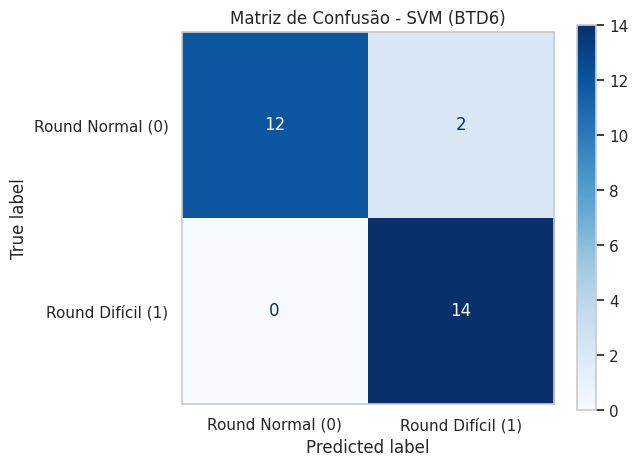

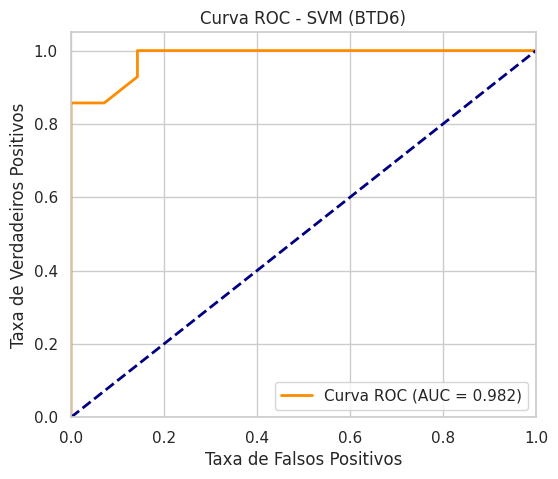

In [78]:
nomes_classes = ['Round Normal (0)', 'Round Difícil (1)']

print('Relatório do Melhor Modelo:\n')
print(classification_report(y_test, y_pred_best,target_names = nomes_classes ))

# Matriz de confusão
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_best,
    display_labels = nomes_classes,
    cmap='Blues', ax=ax
)

# Matriz de Confusão
plt.title('Matriz de Confusão - SVM (BTD6)', fontsize=12)
plt.grid(False) # Remove as linhas de grade por cima das cores
plt.show()

# Curva ROC e AUC
# decision_function pega na pontuação de confiança do modelo para gerar a curva
y_scores = best_model.decision_function(X_test)
fpr, tpr, thresholds = roc_curve(y_test, y_scores)
auc_score = roc_auc_score(y_test, y_scores)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Curva ROC (AUC = {auc_score:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # Linha de aleatoriedade
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taxa de Falsos Positivos')
plt.ylabel('Taxa de Verdadeiros Positivos')
plt.title('Curva ROC - SVM (BTD6)')
plt.legend(loc="lower right")
plt.show()
